## 1) Création de l'entité initiale

On commence avec un catalogue de fichiers CSV qui contiennent les données de nos entreprises. On cherche à trouver, stocker et analyser les données des trois entreprises : **Google** (`0878.065.378`), **Apple** (`0836.157.420`) et **SNCB** (`0203.430.576`).

Les fichiers KBO Open Data se trouvent dans `/home/jovyan/work/data/KBO/` :

| Fichier | Contenu |
|---|---|
| `enterprise.csv` | Statut, forme juridique, date de création |
| `denomination.csv` | Dénominations officielles (FR / NL) |
| `address.csv` | Adresses (siège, exploitation…) |
| `activity.csv` | Codes d'activité NACE |
| `contact.csv` | Téléphone, e-mail, site web |
| `establishment.csv` | Unités d'établissement |
| `code.csv` | Table de correspondance des codes → libellés |

### 🔍 Recherche — Google

In [ ]:
## Chargement des fichiers KBO
# Les fichiers CSV KBO sont stockés en local sous données/
import pandas as pd

DATA_DIR = "données"

enterprise_df    = pd.read_csv(f"{DATA_DIR}/enterprise.csv", dtype=str)
denomination_df  = pd.read_csv(f"{DATA_DIR}/denomination.csv", dtype=str)
address_df       = pd.read_csv(f"{DATA_DIR}/address.csv", dtype=str)
activity_df      = pd.read_csv(f"{DATA_DIR}/activity.csv", dtype=str)
contact_df       = pd.read_csv(f"{DATA_DIR}/contact.csv", dtype=str)
establishment_df = pd.read_csv(f"{DATA_DIR}/establishment.csv", dtype=str)
code_df          = pd.read_csv(f"{DATA_DIR}/code.csv", dtype=str)

print("Fichiers chargés.")
print(f"  {'enterprise':<14}: {len(enterprise_df):>8,} lignes")
print(f"  {'denomination':<14}: {len(denomination_df):>8,} lignes")
print(f"  {'address':<14}: {len(address_df):>8,} lignes")
print(f"  {'activity':<14}: {len(activity_df):>8,} lignes")
print(f"  {'contact':<14}: {len(contact_df):>8,} lignes")
print(f"  {'establishment':<14}: {len(establishment_df):>8,} lignes")
print(f"  {'codes':<14}: {len(code_df):>8,} lignes")

# Numéros des entreprises étudiées
GOOGLE_NUM = "0878.065.378"
APPLE_NUM  = "0836.157.420"
SNCB_NUM   = "0203.430.576"


def get_entity(numero):
    """Rassemble toutes les lignes KBO liées à un numéro d'entreprise."""
    ent_match = enterprise_df[enterprise_df["EnterpriseNumber"] == numero]
    if ent_match.empty:
        return None
    ent = ent_match.iloc[0]

    denoms = denomination_df[denomination_df["EntityNumber"] == numero]
    nom = numero
    principales = denoms[denoms["TypeOfDenomination"] == "001"]
    if not principales.empty:
        nom = principales.iloc[0]["Denomination"]
        for langue in ["1", "2", "3", "4", "0"]:
            match = principales[principales["Language"] == langue]
            if not match.empty:
                nom = match.iloc[0]["Denomination"]
                break
    elif not denoms.empty:
        nom = denoms.iloc[0]["Denomination"]

    adresses = address_df[address_df["EntityNumber"] == numero]
    siege = adresses[adresses["TypeOfAddress"] == "REGO"]
    adresse = siege.iloc[0] if not siege.empty else (adresses.iloc[0] if not adresses.empty else None)

    return {
        "numero": numero,
        "nom": nom,
        "enterprise": ent,
        "denominations": denoms,
        "adresse": adresse,
        "activites": activity_df[activity_df["EntityNumber"] == numero],
        "contacts": contact_df[contact_df["EntityNumber"] == numero],
        "etablissements": establishment_df[establishment_df["EnterpriseNumber"] == numero],
    }


def afficher_entity(entity):
    """Affiche les informations brutes (codes KBO non traduits) d'une entité."""
    if entity is None:
        print("Entité introuvable.")
        return

    def ligne(label, valeur):
        print(f"  {label:<19}: {valeur}")

    ent = entity["enterprise"]
    adresse = entity["adresse"]
    activites = entity["activites"]
    contacts = entity["contacts"]

    print("=" * 60)
    print(f"  {entity['nom']}  ({entity['numero']})")
    print("=" * 60)
    ligne("Statut", ent["Status"])
    ligne("Situation juridique", ent["JuridicalSituation"])
    ligne("Forme juridique", ent["JuridicalForm"])
    ligne("Type d'entreprise", ent["TypeOfEnterprise"])
    ligne("Date de création", ent["StartDate"])

    if adresse is not None:
        rue = adresse["StreetFR"] or adresse["StreetNL"]
        ville = adresse["MunicipalityFR"] or adresse["MunicipalityNL"]
        adresse_str = f"{rue} {adresse['HouseNumber']}, {adresse['Zipcode']} {ville}"
        if adresse.get("Box"):
            adresse_str += f" bte {adresse['Box']}"
    else:
        adresse_str = "—"
    ligne("Adresse", adresse_str)

    print("  Activités")
    for version in sorted(activites["NaceVersion"].unique(), reverse=True):
        print(f"    NACE {version} :")
        sous_ensemble = activites[activites["NaceVersion"] == version].sort_values("Classification", kind="stable")
        for _, a in sous_ensemble.iterrows():
            print(f"      {a['NaceCode']}  [{a['Classification']}]  groupe {a['ActivityGroup']}")

    ligne("Téléphone", list(contacts[contacts["ContactType"] == "TEL"]["Value"]))
    ligne("Email", list(contacts[contacts["ContactType"] == "EMAIL"]["Value"]))
    ligne("Site web", list(contacts[contacts["ContactType"] == "WEB"]["Value"]))
    ligne("Etablissements", len(entity["etablissements"]))

    print()
    print("  Dénominations :")
    print(entity["denominations"][["Language", "TypeOfDenomination", "Denomination"]].to_string(index=False))


In [24]:
google = get_entity(GOOGLE_NUM)
afficher_entity(google)

  GOOGLE BELGIUM  (0878.065.378)
  Statut             : AC
  Situation juridique: 000
  Forme juridique    : 014
  Type d'entreprise  : 2
  Date de création   : 21-12-2005
  Adresse            : Chaussée d'Etterbeek 180, 1040 Bruxelles bte nan
  Activités
    NACE 2025 :
      73110  [MAIN]  groupe 006
      62900  [MAIN]  groupe 001
    NACE 2008 :
      73110  [MAIN]  groupe 006
      62090  [MAIN]  groupe 001
    NACE 2003 :
      74401  [MAIN]  groupe 006
      72600  [MAIN]  groupe 001
  Téléphone          : []
  Email              : []
  Site web           : []
  Etablissements     : 1

  Dénominations :
Language TypeOfDenomination   Denomination
       2                001 GOOGLE BELGIUM


### 🔍 Recherche — Apple

In [12]:
apple = get_entity(APPLE_NUM)
afficher_entity(apple)

  APPLE RETAIL BELGIUM  (0836.157.420)
  Statut             : AC
  Situation juridique: 000
  Forme juridique    : 610
  Type d'entreprise  : 2
  Date de création   : 06-05-2011
  Adresse            : Boulevard Saint-Lazare 4-10, 1210 Saint-Josse-ten-Noode
  Activités
    NACE 2025 :
      47400  [MAIN]  groupe 006
      47400  [MAIN]  groupe 001
    NACE 2008 :
      47410  [MAIN]  groupe 006
      47410  [MAIN]  groupe 001
  Téléphone          : []
  Email              : []
  Site web           : []
  Etablissements     : 2

  Dénominations :
Language TypeOfDenomination         Denomination
       2                001 APPLE RETAIL BELGIUM



### 🔍 Recherche — SNCB

In [13]:
sncb = get_entity(SNCB_NUM)
afficher_entity(sncb)

  SOCIÉTÉ NATIONALE DES CHEMINS DE FER BELGES  (0203.430.576)
  Statut             : AC
  Situation juridique: 000
  Forme juridique    : 114
  Type d'entreprise  : 2
  Date de création   : 01-01-1968
  Adresse            : Rue de France 56, 1060 Saint-Gilles
  Activités
    NACE 2025 :
      49110  [MAIN]  groupe 001
      80010  [SECO]  groupe 001
    NACE 2008 :
      49100  [MAIN]  groupe 001
      80100  [SECO]  groupe 001
    NACE 2003 :
      74601  [SECO]  groupe 001
  Téléphone          : []
  Email              : []
  Site web           : []
  Etablissements     : 270

  Dénominations :
Language TypeOfDenomination                                    Denomination
       1                001     SOCIÉTÉ NATIONALE DES CHEMINS DE FER BELGES
       1                002                                            SNCB
       2                001 NATIONALE MAATSCHAPPIJ DER BELGISCHE SPOORWEGEN
       2                002                                            NMBS



### 🔄 Traduction des codes CSV

On traduit maintenant les codes issus des fichiers CSV en valeurs lisibles (libellés, catégories, etc.).

In [ ]:
def traduire(categorie, code, langue="FR"):
    """Traduit un code KBO (categorie + code) en libellé lisible via code.csv."""
    if not code:
        return "—"
    match = code_df[
        (code_df["Category"] == categorie)
        & (code_df["Code"] == code)
        & (code_df["Language"] == langue)
    ]
    return match.iloc[0]["Description"] if not match.empty else code


def afficher_entity_traduit(entity):
    """Affiche les informations d'une entité avec les codes KBO traduits."""
    if entity is None:
        print("Entité introuvable.")
        return

    def ligne(label, valeur):
        print(f"  {label:<22}: {valeur}")

    ent = entity["enterprise"]
    adresse = entity["adresse"]
    activites = entity["activites"]
    contacts = entity["contacts"]

    print("=" * 60)
    print(f"  {entity['nom']}  ({entity['numero']})")
    print("=" * 60)
    ligne("Nom", entity["nom"])
    ligne("Numéro BCE", entity["numero"])
    ligne("Statut", traduire("Status", ent["Status"]))
    ligne("Situation juridique", traduire("JuridicalSituation", ent["JuridicalSituation"]))
    ligne("Forme juridique", traduire("JuridicalForm", ent["JuridicalForm"]))
    ligne("Type d'entreprise", traduire("TypeOfEnterprise", ent["TypeOfEnterprise"]))
    ligne("Date de création", ent["StartDate"])

    if adresse is not None:
        rue = adresse["StreetFR"] or adresse["StreetNL"]
        ville = adresse["MunicipalityFR"] or adresse["MunicipalityNL"]
        adresse_str = f"{rue} {adresse['HouseNumber']}, {adresse['Zipcode']} {ville}"
        if adresse.get("Box"):
            adresse_str += f" bte {adresse['Box']}"
        type_adresse = traduire("TypeOfAddress", adresse["TypeOfAddress"])
    else:
        adresse_str = "—"
        type_adresse = "—"
    ligne("Adresse", adresse_str)
    ligne("Type d'adresse", type_adresse)

    print("Activités")
    for version in sorted(activites["NaceVersion"].unique(), reverse=True):
        print(f"    NACE {version} :")
        sous_ensemble = activites[activites["NaceVersion"] == version].sort_values("Classification", kind="stable")
        for _, a in sous_ensemble.iterrows():
            classification = traduire("Classification", a["Classification"])
            description = traduire(f"Nace{version}", a["NaceCode"])
            groupe = traduire("ActivityGroup", a["ActivityGroup"])
            print(f"      [{classification}]  {a['NaceCode']} — {description}  ({groupe})")

    telephones = list(contacts[contacts["ContactType"] == "TEL"]["Value"])
    emails = list(contacts[contacts["ContactType"] == "EMAIL"]["Value"])
    sites = list(contacts[contacts["ContactType"] == "WEB"]["Value"])
    ligne("Téléphone", ", ".join(telephones) if telephones else "—")
    ligne("Email", ", ".join(emails) if emails else "—")
    ligne("Site web", ", ".join(sites) if sites else "—")
    ligne("Nb établissements", len(entity["etablissements"]))
    print()


for entity in [google, apple, sncb]:
    afficher_entity_traduit(entity)


## Tableau comparatif des trois entreprises (codes traduits)
comparaison = pd.DataFrame({
    entity["nom"]: {
        "Numéro BCE": entity["numero"],
        "Statut": traduire("Status", entity["enterprise"]["Status"]),
        "Situation juridique": traduire("JuridicalSituation", entity["enterprise"]["JuridicalSituation"]),
        "Forme juridique": traduire("JuridicalForm", entity["enterprise"]["JuridicalForm"]),
        "Type d'entreprise": traduire("TypeOfEnterprise", entity["enterprise"]["TypeOfEnterprise"]),
        "Date de création": entity["enterprise"]["StartDate"],
        "Codes NACE": ", ".join(entity["activites"]["NaceCode"]),
        "Nb établissements": len(entity["etablissements"]),
    }
    for entity in [google, apple, sncb]
})
comparaison.index.name = "Entreprise"
print(comparaison)


In [ ]:
## output after code transformations

---
## 2) Informations supplémentaires externes (KBO)

À partir d'ici, on récupère des données plus riches depuis le **Carrefour des Entreprises Belges (KBO/BCE)**.

URL de référence :  
`https://kbopub.economie.fgov.be/kbopub/toonondernemingps.html?ondernemingsnummer=<NUMERO>`

Exemple : https://kbopub.economie.fgov.be/kbopub/toonondernemingps.html?ondernemingsnummer=203430576

In [ ]:
## Numéros d'entreprise (format KBO sans points pour l'URL)
GOOGLE_NUM_URL = "878065378"
APPLE_NUM_URL  = "836157420"
SNCB_NUM_URL   = "203430576"

BASE_URL = "https://kbopub.economie.fgov.be/kbopub/toonondernemingps.html"

## Scraping KBO pour chaque entreprise
# → récupérer le HTML de la page et parser les sections ci-dessous
import requests
from bs4 import BeautifulSoup

HEADERS_KBO = {"User-Agent": "Mozilla/5.0 (compatible; BCE-research-script)"}


def recuperer_html_kbo(numero_url, langue="fr"):
    """Télécharge le HTML de la fiche publique BCE pour un numéro d'entreprise (sans points)."""
    reponse = requests.get(
        BASE_URL,
        params={"ondernemingsnummer": numero_url, "lang": langue},
        headers=HEADERS_KBO,
        timeout=15,
    )
    reponse.raise_for_status()
    reponse.encoding = "utf-8"
    return reponse.text


def parser_sections_kbo(html):

    soup = BeautifulSoup(html, "html.parser")
    table = soup.find("div", id="table")

    sections = {}
    section_courante = None
    for ligne in table.find_all("tr"):
        titre = ligne.find("h2")
        if titre is not None:
            section_courante = titre.get_text(strip=True)
            sections[section_courante] = []
            continue
        if section_courante is None:
            continue
        cellules = [c.get_text(" ", strip=True) for c in ligne.find_all("td", recursive=False)]
        cellules = [c for c in cellules if c]
        if cellules:
            sections[section_courante].append(cellules)

    return sections, soup


## Récupération + parsing pour Google, Apple et SNCB
ENTREPRISES_KBO = {
    "Google": (GOOGLE_NUM_URL, GOOGLE_NUM),
    "Apple": (APPLE_NUM_URL, APPLE_NUM),
    "SNCB": (SNCB_NUM_URL, SNCB_NUM),
}

kbo_pages = {}
for nom, (numero_url, numero) in ENTREPRISES_KBO.items():
    html = recuperer_html_kbo(numero_url)
    sections, soup = parser_sections_kbo(html)
    kbo_pages[numero] = {"nom": nom, "soup": soup, "sections": sections}

for numero, page in kbo_pages.items():
    titres = ", ".join(page["sections"].keys())
    print(f"  {page['nom']:<8} ({numero}) : {len(page['sections'])} sections — {titres}")


---
### 2.1) Informations Générales

| Champ | Valeur |
|---|---|
| Dénomination | |
| Numéro d'entreprise | |
| Adresse | |
| Activité principale | |
| Effectif | |
| Date de création | |

In [ ]:
## Extraction — Informations Générales
import re

def nettoyer_adresse(texte):
    """Isole la portion adresse d'une cellule BCE (coupe les mentions 'Info supplémentaires' et 'Depuis le')."""
    texte = re.split(r"\s+Info suppl[ée]mentaires", texte)[0]
    texte = re.split(r"\s+Depuis le\s", texte)[0]
    return texte.replace("\xa0", " ").strip()


def activite_principale_locale(numero):
    """Récupère l'activité principale (Classification == MAIN) la plus récente depuis les CSV KBO."""
    activites = get_entity(numero)["activites"]
    principales = activites[activites["Classification"] == "MAIN"]
    if principales.empty:
        return "—"
    ligne = principales.sort_values("NaceVersion", ascending=False).iloc[0]
    libelle = traduire(f"Nace{ligne['NaceVersion']}", ligne["NaceCode"])
    return f"{ligne['NaceCode']} — {libelle}"


def extraire_informations_generales(numero):
    """Extrait les informations générales (section 2.1) depuis la fiche BCE et les CSV KBO."""
    champs = {
        ligne[0].rstrip(":"): ligne[1]
        for ligne in kbo_pages[numero]["sections"]["Généralités"]
        if len(ligne) == 2
    }
    denomination = champs.get("Dénomination", kbo_pages[numero]["nom"]).split(" Dénomination en ")[0].strip()

    return {
        "Dénomination": denomination,
        "Numéro d'entreprise": champs.get("Numéro d'entreprise", numero),
        "Adresse": nettoyer_adresse(champs.get("Adresse du siège", "—")),
        "Activité principale": activite_principale_locale(numero),
        "Effectif": "Non disponible sur la fiche BCE (voir comptes annuels NBB, section 3)",
        "Date de création": champs.get("Date de début", "—"),
    }


informations_generales = pd.DataFrame({
    kbo_pages[numero]["nom"]: extraire_informations_generales(numero)
    for numero in [GOOGLE_NUM, APPLE_NUM, SNCB_NUM]
})
informations_generales.index.name = "Champ"
print(informations_generales)


---
### 2.2) Informations Juridiques

| Champ | Valeur |
|---|---|
| Forme juridique | |
| Numéro de TVA | |
| Situation juridique | |
| Capital social | |
| Assemblée générale | |
| Date de fin de l'année comptable | |

In [ ]:
## Extraction — Informations Juridiques
import re

def couper_depuis(texte):
    """Coupe la mention ' Depuis le ...' à la fin d'une valeur de la fiche BCE."""
    return re.split(r"\s+Depuis le\s", texte)[0].replace("\xa0", " ").strip()


def extraire_informations_juridiques(numero):
    """Extrait les informations juridiques (section 2.2) depuis la fiche BCE."""
    sections = kbo_pages[numero]["sections"]
    champs_generalites = {
        ligne[0].rstrip(":"): ligne[1]
        for ligne in sections["Généralités"]
        if len(ligne) == 2
    }
    champs_financiers = {ligne[0]: ligne[1] for ligne in sections["Données financières"] if len(ligne) == 2}
    qualites = " ".join(ligne[0] for ligne in sections.get("Qualités", []))
    numero_tva = f"BE{numero.replace('.', '')}" if "Assujettie à la TVA" in qualites else "—"

    return {
        "Forme juridique": couper_depuis(champs_generalites.get("Forme légale", "—")),
        "Numéro de TVA": numero_tva,
        "Situation juridique": couper_depuis(champs_generalites.get("Situation juridique", "—")),
        "Capital social": champs_financiers.get("Capital", "—").replace("\xa0", " "),
        "Assemblée générale": champs_financiers.get("Assemblée générale", "—"),
        "Date de fin de l'année comptable": champs_financiers.get("Date de fin de l'année comptable", "—"),
    }


informations_juridiques = pd.DataFrame({
    kbo_pages[numero]["nom"]: extraire_informations_juridiques(numero)
    for numero in [GOOGLE_NUM, APPLE_NUM, SNCB_NUM]
})
informations_juridiques.index.name = "Champ"
print(informations_juridiques)


---
### 2.3) Activités

Liste de chaque domaine d'activité avec son code NACE/ONSS.

| Code | Description |
|---|---|

In [ ]:
## Extraction — Activités
import re

PATTERN_ACTIVITE = re.compile(r"(TVA|ONSS)\s*(\d{4})\s*([\d.]+)\s*-\s*(.+?)\s*Depuis le")


def extraire_activites(numero):
    """Extrait les activités NACE/ONSS (section 2.3) depuis la fiche BCE."""
    lignes_activites = []
    for titre, lignes in kbo_pages[numero]["sections"].items():
        if not titre.startswith("Activités"):
            continue
        for ligne in lignes:
            texte = re.sub(r"\s+", " ", ligne[0].replace("\xa0", " ")).strip()
            match = PATTERN_ACTIVITE.match(texte)
            if match is None:
                continue
            type_activite, version, code, description = match.groups()
            lignes_activites.append({
                "Type": type_activite,
                "Version NACE": version,
                "Code": code,
                "Description": description.strip(),
            })
    return pd.DataFrame(lignes_activites).sort_values(
        ["Version NACE", "Type"], ascending=[False, True], kind="stable"
    ).reset_index(drop=True)


activites = {kbo_pages[numero]["nom"]: extraire_activites(numero) for numero in [GOOGLE_NUM, APPLE_NUM, SNCB_NUM]}

for nom, df in activites.items():
    print(f"--- {nom} ---")
    print(df[["Code", "Description"]].to_string(index=False))
    print()


---
### 2.4) Dirigeants et Représentants

Liste de chaque dirigeant avec sa ou ses qualité(s).

| Nom | Qualité(s) |
|---|---|

In [ ]:
## Extraction — Dirigeants
import re

def extraire_dirigeants(numero):
    """Extrait les dirigeants et leurs qualités (section 2.4) depuis la fiche BCE."""
    lignes = kbo_pages[numero]["sections"].get("Fonctions", [])
    dirigeants_par_nom = {}
    for ligne in lignes:
        if len(ligne) != 3:
            continue
        role, nom_brut, _date = ligne
        nom = re.sub(r"\s*,\s*", ", ", re.sub(r"\s+", " ", nom_brut.replace("\xa0", " "))).strip()
        dirigeants_par_nom.setdefault(nom, []).append(role.strip())
    return [{"nom": nom, "qualites": qualites} for nom, qualites in dirigeants_par_nom.items()]


dirigeants = {kbo_pages[numero]["nom"]: extraire_dirigeants(numero) for numero in [GOOGLE_NUM, APPLE_NUM, SNCB_NUM]}

for nom_entreprise, liste in dirigeants.items():
    print(f"--- {nom_entreprise} ({len(liste)} dirigeant(s)) ---")
    for d in liste:
        print(f"  {d['nom']:<30} {', '.join(d['qualites'])}")
    print()


---
### 2.5) Liens entre Entités

Liste de chaque entité liée à l'entreprise.

| Entité | Numéro d'entreprise | Date du lien | Nature du lien | Statut actuel |
|---|---|---|---|---|

In [ ]:
## Extraction — Liens entre entités
import re

PATTERN_LIEN = re.compile(r"^([\d.]+)\s*\(([^)]+)\)\s*(.+?)\s*depuis le\s+(.+)$")


def extraire_liens(numero):
    """Extrait les liens entre entités (section 2.5) depuis la fiche BCE."""
    liens = []
    for ligne in kbo_pages[numero]["sections"].get("Liens entre entités", []):
        texte = re.sub(r"\s+", " ", ligne[0].replace("\xa0", " ")).strip()
        match = PATTERN_LIEN.match(texte)
        if match is None:
            continue
        numero_lie, entite, nature, date_lien = match.groups()
        liens.append({
            "entite": entite.strip(),
            "numero": numero_lie.strip(),
            "date_lien": date_lien.strip(),
            "nature": nature.strip(),
            "statut": "Actif",
        })
    return liens


liens_entites = {kbo_pages[numero]["nom"]: extraire_liens(numero) for numero in [GOOGLE_NUM, APPLE_NUM, SNCB_NUM]}

for nom_entreprise, liste in liens_entites.items():
    print(f"--- {nom_entreprise} ({len(liste)} lien(s)) ---")
    for lien in liste:
        print(f"  {lien['numero']}  {lien['entite']:<60} {lien['nature']} (depuis le {lien['date_lien']})")
    print()


---
### 2.6) Documents Juridiques (Statuts)

Source : https://statuts.notaire.be/stapor_v1/enterprise/{numero}/statutes

| Document | Date | Lien |
|---|---|---|

In [ ]:
## Extraction — Documents juridiques (Statuts Notaire)
# je ne suis pas arrivée à contourner le contrôle anti-bot


---
### 2.7) Comptes Annuels

Source : https://consult.cbso.nbb.be/consult-enterprise/{numero}

**Stratégie de stockage :**
- **PDFs** — tous les dépôts depuis l'an 2000 → stockés sur HDFS sous `/data/nbb/pdfs/{numero}/{annee}.pdf`
- **CSVs** — le téléchargement est tenté pour **tous** les dépôts disponibles (l'export CSV de consultation NBB dépend des données structurées stockées, pas du format ou de l'année du dépôt d'origine) → stockés sur HDFS sous `/data/nbb/csvs/{numero}/{annee}.csv`. Disponibilité réelle vérifiée au cas par cas, pas présumée par année.

> Exclure les comptes **consolidés** (modèle `mc-*`) et dédupliquer à **un seul dépôt par année** (préférer FR sur NL).

| Année fiscale | Date de publication | PDF | CSV |
|---|---|---|---|

In [ ]:
## Extraction — Comptes Annuels (NBB/CBSO) + stockage HDFS
import re
import time
import requests
from hdfs import InsecureClient

CBSO_API = "https://consult.cbso.nbb.be/api"
HDFS_CLIENT = InsecureClient("http://localhost:9870", user="root")
HDFS_CLIENT.makedirs("/data/nbb")


def recuperer_depots(numero_url):
    """Récupère tous les dépôts publiés (toutes pages) pour un numéro d'entreprise, triés du plus récent au plus ancien."""
    depots = []
    page = 0
    while True:
        reponse = requests.get(
            f"{CBSO_API}/rs-consult/published-deposits",
            params={
                "page": page,
                "size": 50,
                "enterpriseNumber": numero_url.zfill(10),
                "sort": "depositDate,desc",
            },
            headers=HEADERS_KBO,
            timeout=15,
        )
        reponse.raise_for_status()
        contenu = reponse.json()
        if not contenu["content"]:
            break
        depots.extend(contenu["content"])
        if page + 1 >= contenu["totalPages"]:
            break
        page += 1
        time.sleep(0.3)
    return depots


MOTS_CONSOLIDE = ("consolid", "geconsolideerd")


def selectionner_un_depot_par_annee(depots):
    """Exclut les comptes consolidés, garde un seul dépôt par année (préférence FR, puis dépôt le plus récent)."""
    par_annee = {}
    for depot in depots:
        modele = (depot.get("modelName") or "").lower()
        if any(mot in modele for mot in MOTS_CONSOLIDE):
            continue
        annee = depot["periodEndDateYear"]
        actuel = par_annee.get(annee)
        if actuel is None:
            par_annee[annee] = depot
            continue
        actuel_fr = actuel["language"] == "FR"
        depot_fr = depot["language"] == "FR"
        if depot_fr and not actuel_fr:
            par_annee[annee] = depot
        elif depot_fr == actuel_fr and depot["depositDate"] > actuel["depositDate"]:
            par_annee[annee] = depot
    return par_annee


def stocker_comptes_annuels(numero, numero_url):
    """Télécharge les PDFs (depuis 2000) et tente le CSV de consultation pour TOUTES les années.

    On ne présume plus d'une coupure « CSV disponible seulement depuis 2021 » : cette hypothèse
    initiale s'est avérée fausse (l'export CSV dépend des données structurées stockées par la NBB,
    pas du format ou de l'année du dépôt d'origine). On tente donc le téléchargement CSV pour chaque
    dépôt, quelle que soit son année, et on se base uniquement sur la réussite réelle de la requête."""
    depots_par_annee = selectionner_un_depot_par_annee(recuperer_depots(numero_url))
    resultats = []

    for annee, depot in sorted(depots_par_annee.items()):
        depot_id = depot["id"]
        ligne = {"annee": annee, "langue": depot["language"], "pdf": False, "csv": False}

        if annee >= 2000:
            reponse = requests.get(f"{CBSO_API}/external/broker/public/deposits/pdf/{depot_id}", headers=HEADERS_KBO, timeout=60)
            if reponse.ok:
                chemin_hdfs = f"/data/nbb/pdfs/{numero}/{annee}.pdf"
                with HDFS_CLIENT.write(chemin_hdfs, overwrite=True) as ecriture:
                    ecriture.write(reponse.content)
                ligne["pdf"] = True
            time.sleep(0.3)

        reponse = requests.get(f"{CBSO_API}/external/broker/public/deposits/consult/csv/{depot_id}", headers=HEADERS_KBO, timeout=60)
        if reponse.ok:
            chemin_hdfs = f"/data/nbb/csvs/{numero}/{annee}.csv"
            with HDFS_CLIENT.write(chemin_hdfs, overwrite=True) as ecriture:
                ecriture.write(reponse.content)
            ligne["csv"] = True
        time.sleep(0.3)

        resultats.append(ligne)

    return pd.DataFrame(resultats)


COMPTES_ANNUELS_URL = {
    GOOGLE_NUM: GOOGLE_NUM_URL,
    APPLE_NUM: APPLE_NUM_URL,
    SNCB_NUM: SNCB_NUM_URL,
}

comptes_annuels = {}
for numero, numero_url in COMPTES_ANNUELS_URL.items():
    nom = kbo_pages[numero]["nom"]
    comptes_annuels[nom] = stocker_comptes_annuels(numero, numero_url)
    print(f"--- {nom} ---")
    print(comptes_annuels[nom].to_string(index=False))
    print()


---
### 2.8) Établissements

Liste de chaque établissement de l'entreprise.

| Numéro | Adresse | Date de création | Activité |
|---|---|---|---|

In [ ]:
## Extraction — Établissements
def extraire_etablissements(numero):
    """Extrait les établissements d'une entreprise (section 2.8) depuis les CSV KBO locaux."""
    etablissements = establishment_df[establishment_df["EnterpriseNumber"] == numero]
    numeros_etab = etablissements["EstablishmentNumber"]

    adresses_etab = address_df[
        address_df["EntityNumber"].isin(numeros_etab) & (address_df["TypeOfAddress"] == "BAET")
    ]
    adresses_par_etab = adresses_etab.groupby("EntityNumber").first()

    activites_etab = activity_df[
        activity_df["EntityNumber"].isin(numeros_etab) & (activity_df["Classification"] == "MAIN")
    ].sort_values("NaceVersion", ascending=False)
    activites_par_etab = activites_etab.groupby("EntityNumber").first()

    lignes = []
    for _, etab in etablissements.iterrows():
        num_etab = etab["EstablishmentNumber"]

        if num_etab in adresses_par_etab.index:
            a = adresses_par_etab.loc[num_etab]
            rue = a["StreetFR"] or a["StreetNL"]
            ville = a["MunicipalityFR"] or a["MunicipalityNL"]
            adresse = f"{rue} {a['HouseNumber']}, {a['Zipcode']} {ville}"
        else:
            adresse = "—"

        if num_etab in activites_par_etab.index:
            a = activites_par_etab.loc[num_etab]
            categorie_nace = f"Nace{a['NaceVersion']}"
            activite = f"{a['NaceCode']} — {traduire(categorie_nace, a['NaceCode'])}"
        else:
            activite = "—"

        lignes.append({
            "Numéro": num_etab,
            "Adresse": adresse,
            "Date de création": etab["StartDate"],
            "Activité": activite,
        })
    return pd.DataFrame(lignes)


etablissements = {kbo_pages[numero]["nom"]: extraire_etablissements(numero) for numero in [GOOGLE_NUM, APPLE_NUM, SNCB_NUM]}

for nom, df in etablissements.items():
    print(f"--- {nom} ({len(df)} établissement(s)) ---")
    print(df.head(10).to_string(index=False))
    print()


--- Google (1 établissement(s)) ---
       Numéro                                  Adresse Date de création                                Activité
2.151.627.472 Chaussée d'Etterbeek 180, 1040 Etterbeek       10-02-2006 73110 — Activités d’agence de publicité

--- Apple (2 établissement(s)) ---
       Numéro                                                 Adresse Date de création                                                                         Activité
2.200.008.005 Boulevard Saint-Lazare 4-10, 1210 Saint-Josse-ten-Noode       06-05-2011 47400 — Commerce de détail d’équipements de l’information et de la communication
2.244.110.935            Avenue de la Toison d'Or 26-28, 1050 Ixelles       19-09-2015 47400 — Commerce de détail d’équipements de l’information et de la communication

--- SNCB (270 établissement(s)) ---
       Numéro                                      Adresse Date de création                                                                                        

---
### 2.9) Publications (eJustice)

Source : https://www.ejustice.just.fgov.be/cgi_tsv/list.pl?language=fr&btw={tva}&page=1

| Date | Référence (NUMAC) | Type | Lien |
|---|---|---|---|

In [ ]:
## Extraction — Publications eJustice
import re
import time
import requests

EJUSTICE_URL = "https://www.ejustice.just.fgov.be/cgi_tsv/article.pl"

# La page DETAIL d'une publication renvoie en réalité tout l'historique des publications
# de l'entité en une seule requête (pas de pagination à gérer côté list.pl).
PATTERN_DATE_NUMAC = re.compile(
    r"(?P<date>\d{4}(?:-\d{2}-\d{2})?)\s*/\s*(?P<numac>[\d.\-]+)\s*"
    r"(?:<font color=blue>(?:&nbsp;)*(?:<a href=\"(?P<lien>[^\"]+)\"[^>]*>IMAGE</a>)?</font>)?\s*$"
)
PATTERN_NOM_ENTITE = re.compile(r"^<font color=blue>.+</font>")


def recuperer_publications_ejustice(numero_url):
    """Télécharge l'historique complet des publications (Annexe Personnes morales) pour un numéro d'entreprise."""
    reponse = requests.get(
        EJUSTICE_URL,
        params={
            "language": "fr",
            "btw_search": numero_url,
            "btw": numero_url,
            "page": 1,
            "la_search": "f",
            "caller": "list",
        },
        headers=HEADERS_KBO,
        timeout=15,
    )
    reponse.raise_for_status()
    reponse.encoding = "iso-8859-1"
    return reponse.text


def parser_publications_ejustice(html):
    """Parse l'historique de publications (section 2.9) : blocs séparés par <hr>, chaque bloc
    contenant le nom de l'entité (si elle change), son adresse, le type/rubrique de la publication,
    puis la ligne date + référence NUMAC + lien PDF."""
    main = re.search(r"<main.*?>(.*?)</main>", html, re.S).group(1)
    publications = []
    for bloc in main.split("<hr>"):
        lignes_brutes = bloc.split("<br>")
        idx = next(
            (i for i in range(len(lignes_brutes) - 1, -1, -1) if PATTERN_DATE_NUMAC.search(lignes_brutes[i].strip())),
            None,
        )
        if idx is None:
            continue
        match = PATTERN_DATE_NUMAC.search(lignes_brutes[idx].strip())

        type_publication = "—"
        for ligne in lignes_brutes[idx - 1::-1]:
            if PATTERN_NOM_ENTITE.match(ligne.strip()):
                break
            texte = re.sub(r"<[^>]+>", "", ligne).replace("\xa0", " ").replace("&nbsp;", " ").strip()
            if texte:
                type_publication = texte
                break

        lien = f"https://www.ejustice.just.fgov.be{match.group('lien')}" if match.group("lien") else "—"
        publications.append({
            "Date": match.group("date"),
            "Référence (NUMAC)": match.group("numac").strip(),
            "Type": type_publication,
            "Lien": lien,
        })
    return pd.DataFrame(publications)


publications = {}
for numero, numero_url in COMPTES_ANNUELS_URL.items():
    html = recuperer_publications_ejustice(numero_url)
    publications[kbo_pages[numero]["nom"]] = parser_publications_ejustice(html)
    time.sleep(0.3)

for nom, df in publications.items():
    print(f"--- {nom} ({len(df)} publication(s)) ---")
    print(df.head(5).to_string(index=False))
    print()


---
### 2.10) Informations de Contact

| Champ | Valeur |
|---|---|
| Téléphone | |
| Email | |
| Site web | |
| Adresse | |

In [ ]:
## Extraction — Informations de Contact
CLES_TELEPHONE = ["Numéro de téléphone", "Numéro de GSM", "Téléphone"]
CLES_EMAIL = ["Adresse e-mail", "Email", "E-mail"]
CLES_SITE_WEB = ["Adresse web", "Site web", "Site internet"]


def _depuis_champs(champs, cles):
    """Renvoie la première valeur trouvée parmi plusieurs libellés possibles de la fiche BCE."""
    for cle in cles:
        if cle in champs:
            return couper_depuis(champs[cle])
    return None


def _depuis_csv(numero, type_contact):
    """Repli sur le CSV KBO local (contact.csv) si l'info n'est pas sur la fiche BCE."""
    valeurs = list(
        contact_df[(contact_df["EntityNumber"] == numero) & (contact_df["ContactType"] == type_contact)]["Value"]
    )
    return ", ".join(valeurs) if valeurs else None


def extraire_informations_contact(numero):
    """Extrait les informations de contact (section 2.10) depuis la fiche BCE, avec repli sur les CSV KBO locaux."""
    champs_generalites = {
        ligne[0].rstrip(":"): ligne[1]
        for ligne in kbo_pages[numero]["sections"]["Généralités"]
        if len(ligne) == 2
    }

    return {
        "Téléphone": _depuis_champs(champs_generalites, CLES_TELEPHONE) or _depuis_csv(numero, "TEL") or "—",
        "Email": _depuis_champs(champs_generalites, CLES_EMAIL) or _depuis_csv(numero, "EMAIL") or "—",
        "Site web": _depuis_champs(champs_generalites, CLES_SITE_WEB) or _depuis_csv(numero, "WEB") or "—",
        "Adresse": nettoyer_adresse(champs_generalites.get("Adresse du siège", "—")),
    }


informations_contact = pd.DataFrame({
    kbo_pages[numero]["nom"]: extraire_informations_contact(numero)
    for numero in [GOOGLE_NUM, APPLE_NUM, SNCB_NUM]
})
informations_contact.index.name = "Champ"
print(informations_contact)


---
## 3) Finances

Tableau financier depuis 2021 (ou depuis la création) jusqu'à 2025, enrichi avec l'EBIT.

### 📊 Tableau des indicateurs financiers

#### Performance
| Indicateur | 2021 | 2022 | 2023 | 2024 | 2025 |
|---|---|---|---|---|---|
| Chiffre d'affaires | | | | | |
| Marge brute | | | | | |
| EBIT (Résultat d'exploitation) | | | | | |
| Résultat net | | | | | |

#### Croissance
| Indicateur | 2021 | 2022 | 2023 | 2024 | 2025 |
|---|---|---|---|---|---|
| Taux de croissance du CA (%) | | | | | |
| Taux de marge brute (%) | | | | | |
| % de marge nette | | | | | |

#### Autonomie Financière
| Indicateur | 2021 | 2022 | 2023 | 2024 | 2025 |
|---|---|---|---|---|---|
| Trésorerie | | | | | |
| Dettes financières | | | | | |
| Dette financière nette | | | | | |

#### Solvabilité
| Indicateur | 2021 | 2022 | 2023 | 2024 | 2025 |
|---|---|---|---|---|---|
| Fonds propres | | | | | |

#### Ressources Humaines & Coûts
| Indicateur | 2021 | 2022 | 2023 | 2024 | 2025 |
|---|---|---|---|---|---|
| Nombre d'employés | | | | | |
| Coûts salariaux (salaires + charges + avantages) | | | | | |
| Employés en % du coût des revenus | | | | | |
| Revenu par employé | | | | | |
| Taxes payées | | | | | |

In [ ]:
## Extraction — Finances (comptes annuels NBB/CBSO depuis HDFS)
import csv
import io
import re

PATTERN_CODE = re.compile(r"^\d+(/\d+)?[A-Z]*P?$")

CODE_CA = "70"
CODE_COUT_MARCHANDISES = "60"
CODE_EBIT = "9901"
CODE_RESULTAT_NET = "9904"
CODE_TRESORERIE = "54/58"
CODE_DETTES_LT = "17"
CODE_DETTES_CT = "43"
CODE_FONDS_PROPRES = "10/15"
CODE_EFFECTIF = "9087"
CODE_COUTS_SALARIAUX = "62"
CODE_TAXES = "670/3"


def lire_comptes_annuels(numero, annee):
    """Lit le CSV des comptes annuels NBB stocké sur HDFS (paires code/valeur) et renvoie un dict {code: valeur}.
    Un code absent signifie que la rubrique n'a pas été déposée (NBB omet les lignes à valeur nulle) —
    on le laisse manquant plutôt que de le forcer à 0, pour ne pas fausser les indicateurs dérivés."""
    chemin_hdfs = f"/data/nbb/csvs/{numero}/{annee}.csv"
    with HDFS_CLIENT.read(chemin_hdfs, encoding="utf-8") as lecture:
        contenu = lecture.read()

    valeurs = {}
    for ligne in csv.reader(io.StringIO(contenu)):
        if len(ligne) != 2:
            continue
        code, valeur = ligne
        if not PATTERN_CODE.match(code):
            continue
        valeurs[code] = float(valeur)
    return valeurs


def annees_disponibles_csv(numero):
    """Années entre 2021 et 2025 pour lesquelles un CSV NBB a été récupéré (section 2.7)."""
    depots = comptes_annuels[kbo_pages[numero]["nom"]]
    annees = depots[depots["csv"]]["annee"].astype(int)
    return sorted(a for a in annees if 2021 <= a <= 2025)


ORDRE_INDICATEURS = [
    "Chiffre d'affaires", "Marge brute", "EBIT (Résultat d'exploitation)", "Résultat net",
    "Taux de croissance du CA (%)", "Taux de marge brute (%)", "% de marge nette",
    "Trésorerie", "Dettes financières", "Dette financière nette",
    "Fonds propres",
    "Nombre d'employés", "Coûts salariaux", "Employés en % du coût des revenus",
    "Revenu par employé", "Taxes payées",
]


def construire_indicateurs_financiers(numero):
    """Construit le tableau d'indicateurs financiers (section 3) pour une entreprise, une colonne par année."""
    indicateurs_par_annee = {}
    for annee in annees_disponibles_csv(numero):
        codes = lire_comptes_annuels(numero, annee)

        ca = codes.get(CODE_CA, float("nan"))
        marge_brute = ca - codes.get(CODE_COUT_MARCHANDISES, 0.0)
        resultat_net = codes.get(CODE_RESULTAT_NET, float("nan"))
        tresorerie = codes.get(CODE_TRESORERIE, 0.0)
        dettes_fin = codes.get(CODE_DETTES_LT, 0.0) + codes.get(CODE_DETTES_CT, 0.0)
        effectif = codes.get(CODE_EFFECTIF, float("nan"))
        couts_salariaux = codes.get(CODE_COUTS_SALARIAUX, float("nan"))

        indicateurs_par_annee[annee] = {
            "Chiffre d'affaires": ca,
            "Marge brute": marge_brute,
            "EBIT (Résultat d'exploitation)": codes.get(CODE_EBIT, float("nan")),
            "Résultat net": resultat_net,
            "Taux de marge brute (%)": marge_brute / ca * 100,
            "% de marge nette": resultat_net / ca * 100,
            "Trésorerie": tresorerie,
            "Dettes financières": dettes_fin,
            "Dette financière nette": dettes_fin - tresorerie,
            "Fonds propres": codes.get(CODE_FONDS_PROPRES, float("nan")),
            "Nombre d'employés": effectif,
            "Coûts salariaux": couts_salariaux,
            "Employés en % du coût des revenus": couts_salariaux / ca * 100,
            "Revenu par employé": ca / effectif,
            "Taxes payées": codes.get(CODE_TAXES, float("nan")),
        }

    df = pd.DataFrame(indicateurs_par_annee)
    df.loc["Taux de croissance du CA (%)"] = df.loc["Chiffre d'affaires"].pct_change() * 100
    df = df.loc[ORDRE_INDICATEURS]
    df.index.name = "Indicateur"
    df.columns.name = "Année"
    return df


finances = {
    kbo_pages[numero]["nom"]: construire_indicateurs_financiers(numero)
    for numero in [GOOGLE_NUM, APPLE_NUM, SNCB_NUM]
}

for nom, df in finances.items():
    print(f"--- {nom} ---")
    print(df.round(2).to_string())
    print()


--- Google ---
Année                                     2021         2022         2023         2024         2025
Indicateur                                                                                        
Chiffre d'affaires                 63066577.13  77386504.66  94095720.51  92512760.63  95789805.45
Marge brute                        63066577.13  77386504.66  94095720.51  92512760.63  95789805.45
EBIT (Résultat d'exploitation)      8711227.55  12796038.26  15185004.55  15164117.26  15216309.18
Résultat net                        6529995.00   9532019.57  12471274.42  12985558.46  12374735.18
Taux de croissance du CA (%)               NaN        22.71        21.59        -1.68         3.54
Taux de marge brute (%)                 100.00       100.00       100.00       100.00       100.00
% de marge nette                         10.35        12.32        13.25        14.04        12.92
Trésorerie                                0.00         0.00         0.00         0.00         

In [27]:
## Graphe Sankey 
import plotly.graph_objects as go

ANNEE_CIBLE = 2025

FOND_SOMBRE = "#0d1117"
COULEUR_TEXTE = "#e6edf3"

COULEURS_NOEUDS = ["#3fb950", "#f85149", "#2ea043", "#58a6ff", "#d4af37", "#f85149"]
COULEURS_NOEUDS_AVEC_COUT_VENTES = ["#3fb950", "#f0883e", "#f85149", "#2ea043", "#58a6ff", "#d4af37", "#f85149"]
COULEUR_COUT_VENTES = "rgba(240,136,62,0.55)"
COULEUR_CHARGES = "rgba(248,81,73,0.55)"
COULEUR_EXPLOITATION = "rgba(46,160,67,0.55)"
COULEUR_NET = "rgba(212,175,55,0.6)"
COULEUR_IMPOTS = "rgba(248,81,73,0.55)"

# juste pour fixer mes positions de noeuds à l'affichage
NOEUDS_X = [0.001, 0.4,  0.4,  0.7,  0.999, 0.999]
NOEUDS_Y = [0.5,   0.85, 0.15, 0.15, 0.05,  0.3]

# idem, avec un noeud "Coût des ventes" en plus juste après le chiffre d'affaires
NOEUDS_X_AVEC_COUT_VENTES = [0.001, 0.3, 0.3,  0.55, 0.75, 0.999, 0.999]
NOEUDS_Y_AVEC_COUT_VENTES = [0.5,   0.9, 0.55, 0.15, 0.15, 0.05,  0.3]


def formater_montant(valeur):
    """Formate un montant en euros, signe conservé : en millions d'euros (1 décimale) au-delà
    de 1 M€, en euros exacts en dessous (sinon des montants comme les impôts d'une petite
    entité — souvent < 1 M€ — s'arrondiraient à 0.0 M€ ou perdraient toute précision utile)."""
    if abs(valeur) >= 1e6:
        return f"{valeur / 1e6:,.1f} M€".replace(",", " ")
    return f"{valeur:,.0f} €".replace(",", " ")


def construire_sankey(numero, annee=ANNEE_CIBLE):
    df = finances[kbo_pages[numero]["nom"]]
    if annee not in df.columns:
        annee_disponible = df.columns[-1]
        print(f"   {kbo_pages[numero]['nom']} : pas de CSV NBB pour {annee}, utilisation de {annee_disponible} à la place.")
        annee = annee_disponible
    valeurs = df[annee]

    ca = valeurs["Chiffre d'affaires"]
    ebit = valeurs["EBIT (Résultat d'exploitation)"]
    charges = ca - ebit
    resultat_net = valeurs["Résultat net"]
    impots = valeurs["Taxes payées"]
    resultat_avant_impots = resultat_net + impots
    cout_ventes = lire_comptes_annuels(numero, annee).get(CODE_COUT_MARCHANDISES)

    def pct(valeur):
        return f"{valeur / ca * 100:.1f}% du CA"

    if cout_ventes is None:
        noeuds = [
            f"Chiffre d'affaires<br>{formater_montant(ca)}",
            f"Charges d'exploitation<br>{formater_montant(charges)} · {pct(charges)}",
            f"Résultat d'exploitation<br>{formater_montant(ebit)} · {pct(ebit)}",
            f"Résultat avant impôts<br>{formater_montant(resultat_avant_impots)}",
            f"Résultat net<br>{formater_montant(resultat_net)} · {pct(resultat_net)}",
            f"Impôts<br>{formater_montant(impots)}",
        ]
        liens = [
            (0, 1, charges, COULEUR_CHARGES),
            (0, 2, ebit, COULEUR_EXPLOITATION),
            (2, 3, resultat_avant_impots, COULEUR_EXPLOITATION),
            (3, 4, resultat_net, COULEUR_NET),
            (3, 5, impots, COULEUR_IMPOTS),
        ]
        couleurs_noeuds, noeuds_x, noeuds_y = COULEURS_NOEUDS, NOEUDS_X, NOEUDS_Y
    else:
        autres_charges = charges - cout_ventes
        noeuds = [
            f"Chiffre d'affaires<br>{formater_montant(ca)}",
            f"Coût des ventes<br>{formater_montant(cout_ventes)} · {pct(cout_ventes)}",
            f"Autres charges d'exploitation<br>{formater_montant(autres_charges)} · {pct(autres_charges)}",
            f"Résultat d'exploitation<br>{formater_montant(ebit)} · {pct(ebit)}",
            f"Résultat avant impôts<br>{formater_montant(resultat_avant_impots)}",
            f"Résultat net<br>{formater_montant(resultat_net)} · {pct(resultat_net)}",
            f"Impôts<br>{formater_montant(impots)}",
        ]
        liens = [
            (0, 1, cout_ventes, COULEUR_COUT_VENTES),
            (0, 2, autres_charges, COULEUR_CHARGES),
            (0, 3, ebit, COULEUR_EXPLOITATION),
            (3, 4, resultat_avant_impots, COULEUR_EXPLOITATION),
            (4, 5, resultat_net, COULEUR_NET),
            (4, 6, impots, COULEUR_IMPOTS),
        ]
        couleurs_noeuds = COULEURS_NOEUDS_AVEC_COUT_VENTES
        noeuds_x, noeuds_y = NOEUDS_X_AVEC_COUT_VENTES, NOEUDS_Y_AVEC_COUT_VENTES

    fig = go.Figure(go.Sankey(
        arrangement="fixed",
        node=dict(
            label=noeuds,
            color=couleurs_noeuds,
            x=noeuds_x,
            y=noeuds_y,
            pad=50,
            thickness=22,
            line=dict(color=FOND_SOMBRE, width=1),
        ),
        link=dict(
            source=[s for s, _, _, _ in liens],
            target=[t for _, t, _, _ in liens],
            value=[abs(v) for _, _, v, _ in liens],
            color=[c for *_, c in liens],
            line=dict(color="rgba(0,0,0,0)", width=0),
        ),
        textfont=dict(size=14, color=COULEUR_TEXTE, family="Arial Black, Arial, sans-serif"),
    ))
    fig.update_layout(
        title=dict(
            text=f"{kbo_pages[numero]['nom']} — Compte de résultats {annee}",
            font=dict(size=22, color=COULEUR_TEXTE, family="Arial Black, Arial, sans-serif"),
            x=0.5,
            xanchor="center",
        ),
        font_size=12,
        width=1100,
        height=520,
        margin=dict(l=10, r=10, t=70, b=10),
        paper_bgcolor=FOND_SOMBRE,
        plot_bgcolor=FOND_SOMBRE,
    )
    return fig


for numero in [GOOGLE_NUM, APPLE_NUM, SNCB_NUM]:
    construire_sankey(numero).show()


---
### 📈 Graphiques — Chiffre d'affaires & Résultat net (2021–2025)

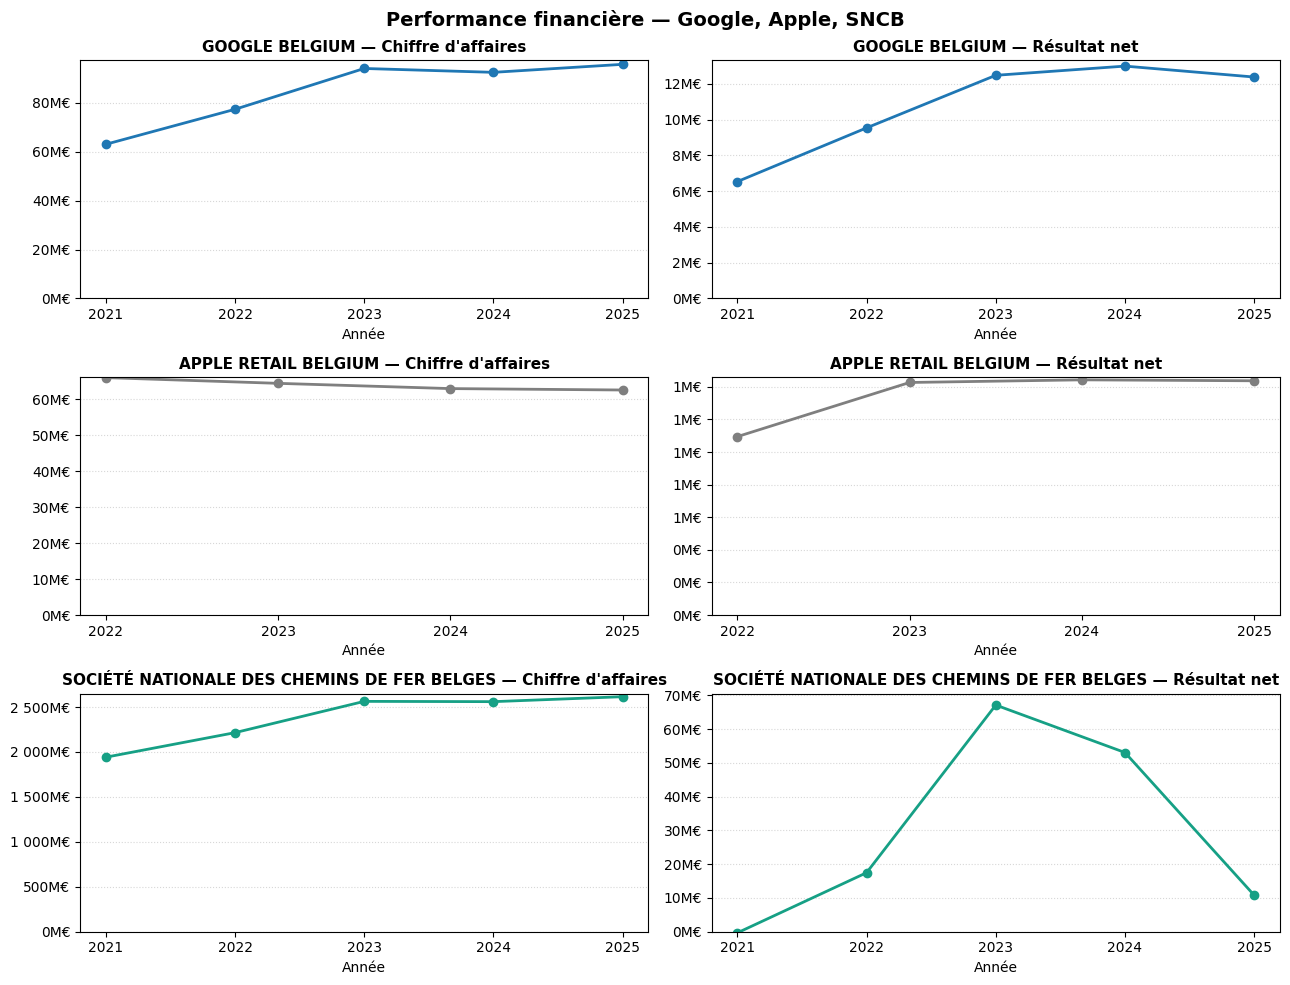

In [22]:
## Graphiques — Chiffre d'affaires & Résultat net (2021–2025)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

COULEURS_ENTREPRISES = {
    "Google": "#1f77b4",
    "Apple": "#7f7f7f",
    "SNCB": "#16a085",
}


def formater_millions(valeur, _position=None):
    """Formate un tick d'axe Y en millions d'euros (ex. 60000000 -> "60M€")."""
    return f"{valeur / 1e6:,.0f}M€".replace(",", " ")


fig, axes = plt.subplots(3, 2, figsize=(13, 10))
fig.suptitle("Performance financière — Google, Apple, SNCB", fontsize=14, fontweight="bold")

for ligne, numero in enumerate([GOOGLE_NUM, APPLE_NUM, SNCB_NUM]):
    nom = kbo_pages[numero]["nom"]
    df = finances[nom]
    couleur = COULEURS_ENTREPRISES[nom]
    nom_affiche = informations_generales[nom]["Dénomination"]

    for colonne, indicateur in enumerate(["Chiffre d'affaires", "Résultat net"]):
        ax = axes[ligne, colonne]
        serie = df.loc[indicateur].dropna()
        ax.plot(serie.index, serie.values, marker="o", color=couleur, linewidth=2)
        ax.set_title(f"{nom_affiche} — {indicateur}", fontsize=11, fontweight="bold")
        ax.set_xlabel("Année")
        ax.set_xticks(serie.index)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(formater_millions))
        ax.set_ylim(bottom=0)
        ax.grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()


---
## 📖 Glossaire des indicateurs financiers

Tous les indicateurs ci-dessous sont calculés à partir des **codes comptables NBB** (Plan Comptable Minimum Normalisé).
Les codes entre parenthèses correspondent aux lignes du CSV téléchargé depuis la NBB.

---

### Performance

| Indicateur | Définition | Formule | Code(s) |
|---|---|---|---|
| **Chiffre d'affaires (CA)** | Revenu total généré par la vente de biens et services sur l'exercice | — | `70` |
| **Marge brute** | Ce qu'il reste après déduction du coût direct des marchandises vendues | CA − Coût des marchandises | `70 − 60` |
| **EBIT** *(Résultat d'exploitation)* | Bénéfice avant intérêts et impôts — mesure la performance opérationnelle pure | — | `9901` |
| **EBITDA** | EBIT avant amortissements — proxy du cash généré par l'exploitation | EBIT + Amortissements | `9901 + 630` |
| **Résultat net** | Bénéfice final après toutes les charges, intérêts et impôts | — | `9904` |

---

### Croissance & Marges

| Indicateur | Définition | Formule |
|---|---|---|
| **Taux de croissance du CA (%)** | Variation du chiffre d'affaires d'une année sur l'autre | `(CA_n − CA_{n-1}) / CA_{n-1} × 100` |
| **Taux de marge brute (%)** | Part de la marge brute dans le CA — reflète la rentabilité commerciale | `Marge brute / CA × 100` |
| **Marge nette (%)** | Part du résultat net dans le CA — résume la rentabilité globale | `Résultat net / CA × 100` |
| **Marge EBITDA (%)** | Capacité à générer du cash avant investissements et fiscalité | `EBITDA / CA × 100` |

---

### Autonomie Financière

| Indicateur | Définition | Formule | Code(s) |
|---|---|---|---|
| **Trésorerie** | Liquidités disponibles immédiatement (banque + caisse) | — | `54/58` |
| **Dettes financières** | Total des emprunts bancaires (long terme + court terme) | Dettes LT + Dettes CT | `17 + 43` |
| **Dette financière nette** | Endettement réel après déduction de la trésorerie disponible. Négatif = position de trésorerie nette (bonne santé) | Dettes financières − Trésorerie | `(17 + 43) − 54/58` |

---

### Solvabilité

| Indicateur | Définition | Formule | Code(s) |
|---|---|---|---|
| **Fonds propres** | Capital apporté par les actionnaires + bénéfices accumulés non distribués | — | `10/15` |
| **Total actif** | Ensemble des ressources économiques contrôlées par l'entreprise | — | `20/58` |
| **Autonomie financière (%)** | Part des actifs financée par les fonds propres (sans recours à la dette). Plus c'est élevé, plus l'entreprise est indépendante | `Fonds propres / Total actif × 100` |

---

### Ressources Humaines

| Indicateur | Définition | Formule | Code(s) |
|---|---|---|---|
| **Effectif FTE moyen** | Nombre moyen d'équivalents temps plein sur l'exercice | — | `9087` |
| **Coûts salariaux** | Rémunérations brutes + cotisations patronales + avantages extra-légaux | — | `62` |
| **Revenu par ETP** | CA généré en moyenne par chaque employé — mesure la productivité | `CA / Effectif FTE` |
| **Coût moyen par ETP** | Coût salarial total rapporté à un équivalent temps plein | `Coûts salariaux / Effectif FTE` |
| **Part salariale dans le CA (%)** | Poids des charges de personnel dans le chiffre d'affaires | `Coûts salariaux / CA × 100` |
| **Taxes payées** | Impôt des sociétés (ISOC) effectivement payé sur l'exercice | — | `670/3` |